# Extração dos Dados

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np

In [2]:
# Carregando os dados
dados = pd.read_csv('/content/telecom_x_data.csv')

In [3]:
# Visualizando as estatísticas descritivas
dados.describe()

,idoso,tempo_contrato,cobrança_mensal,cobrança_total,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159891
std,0.368844,24.545260,30.085974,2266.771362,1.002955
min,0.000000,1.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.587500,401.450000,1.187500
50%,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,0.000000,55.000000,89.862500,3794.737500,2.992500
max,1.000000,72.000000,118.750000,8684.800000,3.960000


In [4]:
# Visualizando as estatísticas categóricas e já observando quantos valores únicos existem em cada coluna
dados.describe(include='O')

,id_cliente,churn,genero,parceiro,dependentes,servico_telefonico,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivos,suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_online,metodo_pagamento
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,não,masculino,não,não,sim,não,fibra ótica,não,não,não,não,não,não,mensal,sim,cheque eletrônico
freq,1,5163,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


# Feature Encoding ()

In [5]:
# importando funções do SciKit-Learn
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [6]:
'''
Separando as variáveis, onde:
>>> x terá apenas as variáveis categoricas
>>> y terá apenas as variáveis numéricas
>>> z terá a variável alvo
'''
x = dados.select_dtypes(include= 'object')
y = dados.select_dtypes(exclude= 'object')
z = dados['churn']

In [7]:
# Excluindo a coluna de identificação e a variável alvo de x
x.drop(columns= ['id_cliente', 'churn'], axis= 1, inplace= True)

In [8]:
# Copiando os nomes das colunas originais
colunas = x.columns

In [9]:
colunas

Index(['genero', 'parceiro', 'dependentes', 'servico_telefonico',
       'multiplas_linhas', 'servico_internet', 'seguranca_online',
       'backup_online', 'protecao_dispositivos', 'suporte_tecnico',
       'streaming_tv', 'streaming_filmes', 'contrato', 'fatura_online',
       'metodo_pagamento'],
      dtype='object')

In [10]:
# Criando um pipeline de pré-processamento para codificação da variável x
one_hot = make_column_transformer(
    (OneHotEncoder(drop= 'if_binary'),
     ['genero', 'parceiro', 'dependentes', 'servico_telefonico',
       'multiplas_linhas', 'servico_internet', 'seguranca_online',
       'backup_online', 'protecao_dispositivos', 'suporte_tecnico',
       'streaming_tv', 'streaming_filmes', 'contrato', 'fatura_online',
       'metodo_pagamento']),
    remainder='passthrough',
    sparse_threshold=0
)

In [11]:
# Aplicando o ajuste e a transformação
x = one_hot.fit_transform(x)

In [12]:
# Recuperando os nomes das colunas pós-transformação
feature_names = one_hot.get_feature_names_out(colunas)

In [13]:
# Criando o DataFrame codificado das variáveis categóricas
x_codificado = pd.DataFrame(x, columns=feature_names)

In [14]:
# Agrupando em um DataFrame as variáveis categóricas já transformadas (x) e as variáveis numéricas (y)
df_x = pd.concat([y, x_codificado], axis=1)
df_x.head()

,idoso,tempo_contrato,cobrança_mensal,cobrança_total,contas_diarias,onehotencoder__genero_masculino,onehotencoder__parceiro_sim,onehotencoder__dependentes_sim,onehotencoder__servico_telefonico_sim,onehotencoder__multiplas_linhas_não,...,onehotencoder__streaming_filmes_sem serviço de internet,onehotencoder__streaming_filmes_sim,onehotencoder__contrato_dois anos,onehotencoder__contrato_mensal,onehotencoder__contrato_um ano,onehotencoder__fatura_online_sim,onehotencoder__metodo_pagamento_cartão de crédito (automático),onehotencoder__metodo_pagamento_cheque eletrônico,onehotencoder__metodo_pagamento_cheque postal,onehotencoder__metodo_pagamento_transferência bancária (automática)
0,0,9,65.6,593.30,2.19,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0,9,59.9,542.40,2.00,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,4,73.9,280.85,2.46,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1,13,98.0,1237.85,3.27,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1,3,83.9,267.40,2.80,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [15]:
# Transformando a variável alvo (z)
label_encoder = LabelEncoder()
z = label_encoder.fit_transform(z)

In [16]:
# Criando o DataFrame final com todas as colunas codificadas
df_encoding = pd.concat([pd.Series(z, name='churn'), df_x], axis=1)
df_encoding.head()

,churn,idoso,tempo_contrato,cobrança_mensal,cobrança_total,contas_diarias,onehotencoder__genero_masculino,onehotencoder__parceiro_sim,onehotencoder__dependentes_sim,onehotencoder__servico_telefonico_sim,...,onehotencoder__streaming_filmes_sem serviço de internet,onehotencoder__streaming_filmes_sim,onehotencoder__contrato_dois anos,onehotencoder__contrato_mensal,onehotencoder__contrato_um ano,onehotencoder__fatura_online_sim,onehotencoder__metodo_pagamento_cartão de crédito (automático),onehotencoder__metodo_pagamento_cheque eletrônico,onehotencoder__metodo_pagamento_cheque postal,onehotencoder__metodo_pagamento_transferência bancária (automática)
0,0,0,9,65.6,593.30,2.19,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0,0,9,59.9,542.40,2.00,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,0,4,73.9,280.85,2.46,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1,1,13,98.0,1237.85,3.27,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1,1,3,83.9,267.40,2.80,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [17]:
# Salvando o DataFrame codificado
df_encoding.to_csv('df_encoding.csv', index=False)

# Analisando a distribuição e limpando os dados

In [18]:
# Identificando colunas constantes
print('--- Verificando Colunas Constantes ---')
colunas_constantes = [col for col in df_encoding.columns if df_encoding[col].nunique() == 1]
if colunas_constantes:
    print(f'Colunas constantes encontradas: {colunas_constantes}')
else:
    print('Nenhuma coluna constante encontrada.')

# Identificando colunas quase constantes (ex: mais de 99% dos valores são iguais)
print('\n--- Verificando Colunas Quase Constantes (limite: 99%) ---')
quase_colunas_constantes = []
for col in df_encoding.columns:
    if df_encoding[col].nunique() > 1:
        value_counts = df_encoding[col].value_counts(normalize=True)
        if value_counts.iloc[0] > 0.99:
            quase_colunas_constantes.append(col)
if quase_colunas_constantes:
    print(f'Colunas quase constantes encontradas: {quase_colunas_constantes}')
else:
    print('Nenhuma coluna quase constante encontrada.')


--- Verificando Colunas Constantes ---
Nenhuma coluna constante encontrada.

--- Verificando Colunas Quase Constantes (limite: 99%) ---
Nenhuma coluna quase constante encontrada.


In [19]:
# Identificando colunas com alta cardinalidade (potenciais identificadores)
# Exemplo: colunas onde o número de valores únicos é >= 90% do total de linhas
print('\n--- Verificando Colunas com Alta Cardinalidade (limite: 90% únicos) ---')
colunas_alta_cardinalidade = []
limite = 0.9 * len(df_encoding)
for col in df_encoding.columns:
    if df_encoding[col].nunique() >= limite:
        colunas_alta_cardinalidade.append(col)
if colunas_alta_cardinalidade:
    print(f'Colunas com alta cardinalidade encontradas: {colunas_alta_cardinalidade}')
else:
    print('Nenhuma coluna com alta cardinalidade encontrada.')



--- Verificando Colunas com Alta Cardinalidade (limite: 90% únicos) ---
Colunas com alta cardinalidade encontradas: ['cobrança_total']


In [20]:
# Removendo a coluna 'cobrança_total' do df_encoding
print(f"Removendo a coluna: 'cobrança_total'")
df_encoding.drop(columns=['cobrança_total'], inplace=True)
print(f"df_encoding agora tem {df_encoding.shape[1]} colunas.")
display(df_encoding.head())

Removendo a coluna: 'cobrança_total'
df_encoding agora tem 41 colunas.


,churn,idoso,tempo_contrato,cobrança_mensal,contas_diarias,onehotencoder__genero_masculino,onehotencoder__parceiro_sim,onehotencoder__dependentes_sim,onehotencoder__servico_telefonico_sim,onehotencoder__multiplas_linhas_não,...,onehotencoder__streaming_filmes_sem serviço de internet,onehotencoder__streaming_filmes_sim,onehotencoder__contrato_dois anos,onehotencoder__contrato_mensal,onehotencoder__contrato_um ano,onehotencoder__fatura_online_sim,onehotencoder__metodo_pagamento_cartão de crédito (automático),onehotencoder__metodo_pagamento_cheque eletrônico,onehotencoder__metodo_pagamento_cheque postal,onehotencoder__metodo_pagamento_transferência bancária (automática)
0,0,0,9,65.6,2.19,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0,0,9,59.9,2.00,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,0,4,73.9,2.46,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1,1,13,98.0,3.27,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1,1,3,83.9,2.80,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0



--- Verificando Colunas com Alta Correlação (limite: |0.9|) ---
Colunas com alta correlação (para remover uma): ['contas_diarias', 'onehotencoder__multiplas_linhas_sem serviço telefônico', 'onehotencoder__seguranca_online_sem serviço de internet', 'onehotencoder__backup_online_sem serviço de internet', 'onehotencoder__protecao_dispositivos_sem serviço de internet', 'onehotencoder__suporte_tecnico_sem serviço de internet', 'onehotencoder__streaming_tv_sem serviço de internet', 'onehotencoder__streaming_filmes_sem serviço de internet']


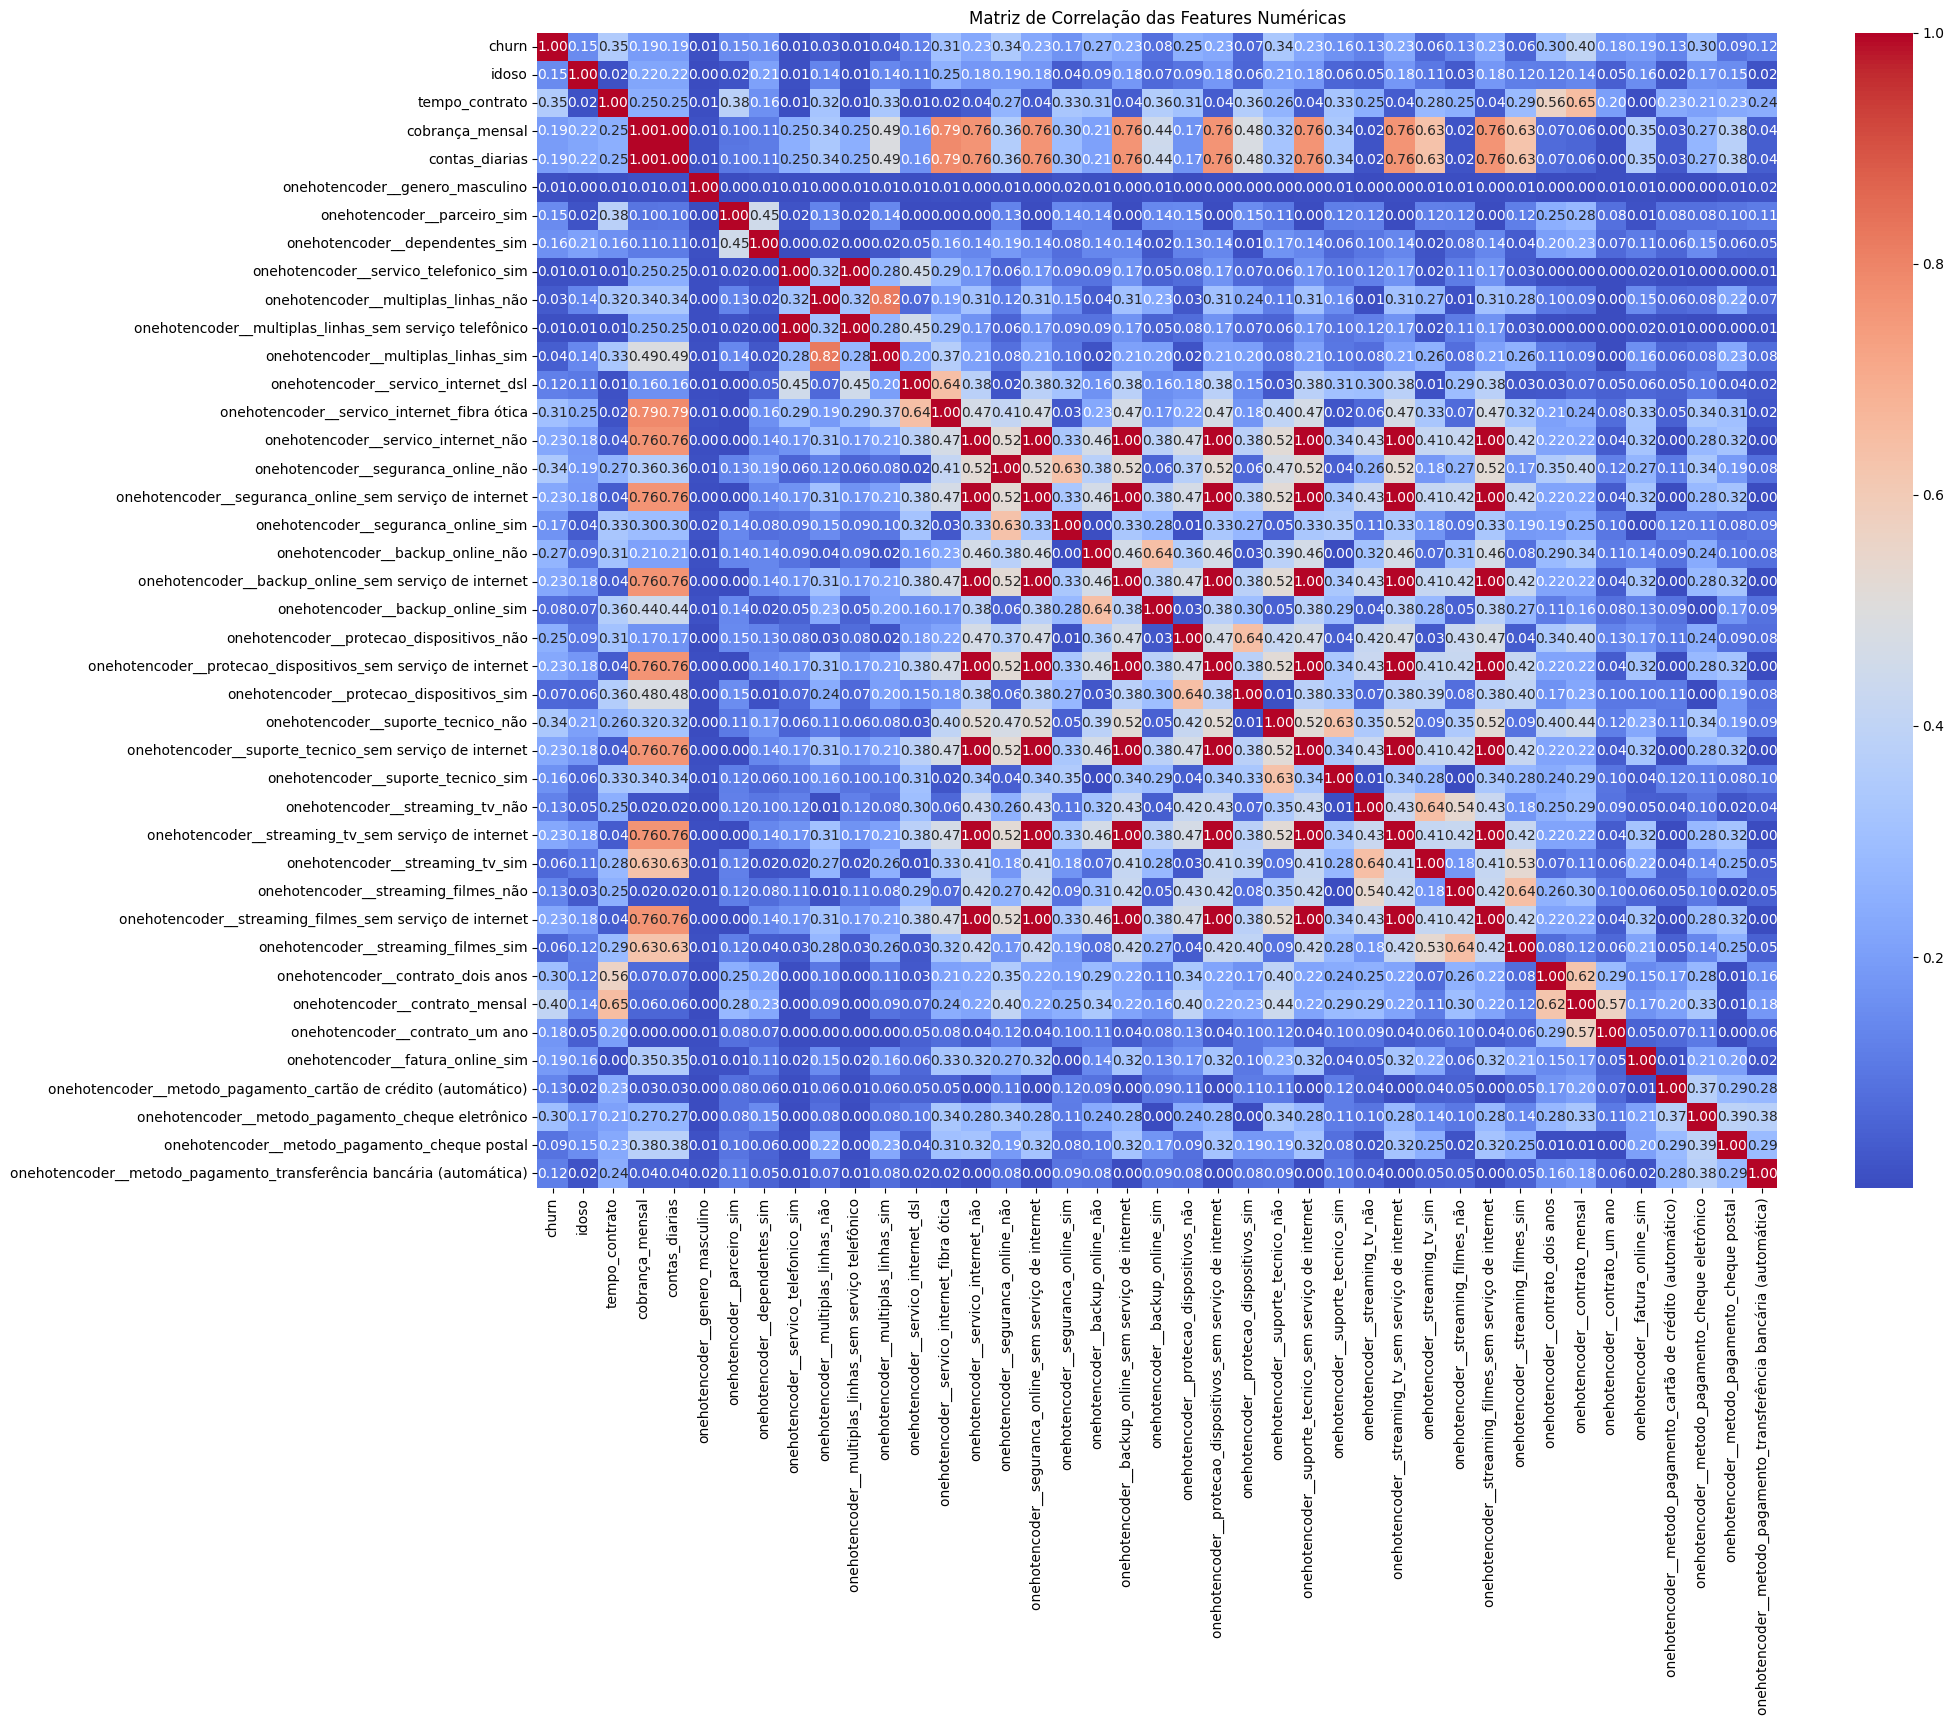

In [21]:
# Análise de Correlação para colunas numéricas
print('\n--- Verificando Colunas com Alta Correlação (limite: |0.9|) ---')
matriz_correlacao = df_encoding.corr(numeric_only=True).abs()

upper_tri = matriz_correlacao.where(np.triu(np.ones(matriz_correlacao.shape), k=1).astype(bool))

retirar_alta_correlacao = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

if retirar_alta_correlacao:
    print(f'Colunas com alta correlação (para remover uma): {retirar_alta_correlacao}')
else:
    print('Nenhuma coluna com alta correlação (>0.90) encontrada.')

# Exibindo a matriz de correlação para uma inspeção visual
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Features Numéricas')
plt.show()


In [22]:
# Removendo as colunas com alta correlação
print(f"Colunas a serem removidas devido à alta correlação: {retirar_alta_correlacao}")
df_encoding.drop(columns=retirar_alta_correlacao, inplace=True)
print(f"df_encoding agora tem {df_encoding.shape[1]} colunas.")
display(df_encoding.head())

Colunas a serem removidas devido à alta correlação: ['contas_diarias', 'onehotencoder__multiplas_linhas_sem serviço telefônico', 'onehotencoder__seguranca_online_sem serviço de internet', 'onehotencoder__backup_online_sem serviço de internet', 'onehotencoder__protecao_dispositivos_sem serviço de internet', 'onehotencoder__suporte_tecnico_sem serviço de internet', 'onehotencoder__streaming_tv_sem serviço de internet', 'onehotencoder__streaming_filmes_sem serviço de internet']
df_encoding agora tem 33 colunas.


,churn,idoso,tempo_contrato,cobrança_mensal,onehotencoder__genero_masculino,onehotencoder__parceiro_sim,onehotencoder__dependentes_sim,onehotencoder__servico_telefonico_sim,onehotencoder__multiplas_linhas_não,onehotencoder__multiplas_linhas_sim,...,onehotencoder__streaming_filmes_não,onehotencoder__streaming_filmes_sim,onehotencoder__contrato_dois anos,onehotencoder__contrato_mensal,onehotencoder__contrato_um ano,onehotencoder__fatura_online_sim,onehotencoder__metodo_pagamento_cartão de crédito (automático),onehotencoder__metodo_pagamento_cheque eletrônico,onehotencoder__metodo_pagamento_cheque postal,onehotencoder__metodo_pagamento_transferência bancária (automática)
0,0,0,9,65.6,0.0,1.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0,0,9,59.9,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,0,4,73.9,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1,1,13,98.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1,1,3,83.9,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [23]:
# Calculando a proporção de clientes que evadiram (churn) vs. permaneceram ativos
cont_churn = df_encoding['churn'].value_counts()
proporcao_churn = df_encoding['churn'].value_counts(normalize=True) * 100

print("Contagem de clientes por classe (0 = Ativo, 1 = Churn):")
print(cont_churn)
print("\nProporção de clientes por classe (0 = Ativo, 1 = Churn):")
print(proporcao_churn.round(2).astype(str) + '%')

# Avaliando o desequilíbrio
if proporcao_churn[1] > 0.6 * proporcao_churn[0] and proporcao_churn[0] > 0.6 * proporcao_churn[1]:
    print("\nNão há desequilíbrio significativo entre as classes. A proporção é relativamente equilibrada.")
elif proporcao_churn[1] > proporcao_churn[0]:
    print(f"\nHá um desequilíbrio significativo. A classe 'churn' (1) representa {proporcao_churn[1]:.2f}% e a classe 'ativo' (0) representa {proporcao_churn[0]:.2f}%. Isso pode impactar modelos preditivos e a análise de resultados.")
else:
    print(f"\nHá um desequilíbrio significativo. A classe 'ativo' (0) representa {proporcao_churn[0]:.2f}% e a classe 'churn' (1) representa {proporcao_churn[1]:.2f}%. Isso pode impactar modelos preditivos e a análise de resultados.")


Contagem de clientes por classe (0 = Ativo, 1 = Churn):
churn
0    5163
1    1869
Name: count, dtype: int64

Proporção de clientes por classe (0 = Ativo, 1 = Churn):
churn
0    73.42%
1    26.58%
Name: proportion, dtype: object

Há um desequilíbrio significativo. A classe 'ativo' (0) representa 73.42% e a classe 'churn' (1) representa 26.58%. Isso pode impactar modelos preditivos e a análise de resultados.


## Aplicando Oversampling (SMOTE)

In [24]:
import sys
!{sys.executable} -m pip install imblearn

In [26]:
from imblearn.over_sampling import SMOTE

X = df_encoding.drop('churn', axis=1)
y = df_encoding['churn']

sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X, y)

print("Contagem de clientes por classe após SMOTE (0 = Ativo, 1 = Churn):")
print(y_smote.value_counts())

Contagem de clientes por classe após SMOTE (0 = Ativo, 1 = Churn):
churn
0    5163
1    5163
Name: count, dtype: int64


## Aplicando o RandomUnderSampler

In [27]:
from imblearn.under_sampling import RandomUnderSampler

X_rus, y_rus = RandomUnderSampler(random_state=42).fit_resample(X, y)

print("Contagem de clientes por classe após RandomUnderSampler (0 = Ativo, 1 = Churn):")
print(y_rus.value_counts())

Contagem de clientes por classe após RandomUnderSampler (0 = Ativo, 1 = Churn):
churn
0    1869
1    1869
Name: count, dtype: int64


## Padronizando os dados (SMOTE)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Aplicando a padronização aos dados X_smote
X_smote_scaled = scaler.fit_transform(X_smote)

# Convertendo o array padronizado de volta para um DataFrame
X_smote_scaled_df = pd.DataFrame(X_smote_scaled, columns=X_smote.columns)

print("Primeiras 5 linhas de X_smote após a padronização:")
display(X_smote_scaled_df.head())

Primeiras 5 linhas de X_smote após a padronização:


,idoso,tempo_contrato,cobrança_mensal,onehotencoder__genero_masculino,onehotencoder__parceiro_sim,onehotencoder__dependentes_sim,onehotencoder__servico_telefonico_sim,onehotencoder__multiplas_linhas_não,onehotencoder__multiplas_linhas_sim,onehotencoder__servico_internet_dsl,...,onehotencoder__streaming_filmes_não,onehotencoder__streaming_filmes_sim,onehotencoder__contrato_dois anos,onehotencoder__contrato_mensal,onehotencoder__contrato_um ano,onehotencoder__fatura_online_sim,onehotencoder__metodo_pagamento_cartão de crédito (automático),onehotencoder__metodo_pagamento_cheque eletrônico,onehotencoder__metodo_pagamento_cheque postal,onehotencoder__metodo_pagamento_transferência bancária (automática)
0,-0.410161,-0.779083,-0.080898,-1.053386,1.169396,1.771262,0.325657,1.080217,-0.893214,1.486149,...,1.175368,-0.840822,-0.455615,-1.413795,2.264414,0.758604,-0.487969,-0.885474,2.001446,-0.495884
1,-0.410161,-0.779083,-0.278153,1.032792,-0.918164,-0.600581,0.325657,-0.963221,1.164885,1.486149,...,-0.876235,1.224277,-0.455615,0.724831,-0.459798,-1.401437,-0.487969,-0.885474,2.001446,-0.495884
2,-0.410161,-0.986922,0.206333,1.032792,-0.918164,-0.600581,0.325657,1.080217,-0.893214,-0.677567,...,1.175368,-0.840822,-0.455615,0.724831,-0.459798,0.758604,-0.487969,1.211044,-0.524113,-0.495884
3,2.438070,-0.612811,1.040342,1.032792,1.169396,-0.600581,0.325657,1.080217,-0.893214,-0.677567,...,-0.876235,1.224277,-0.455615,0.724831,-0.459798,0.758604,-0.487969,1.211044,-0.524113,-0.495884
4,2.438070,-1.028490,0.552395,-1.053386,1.169396,-0.600581,0.325657,1.080217,-0.893214,-0.677567,...,1.175368,-0.840822,-0.455615,0.724831,-0.459798,0.758604,-0.487969,-0.885474,2.001446,-0.495884


In [29]:
# Dividindo os dados em conjuntos de treinamento e teste
# Usaremos o X_smote_scaled_df (dados padronizados e com oversampling)
# e y_smote (a variável alvo com oversampling)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_smote_scaled_df, y_smote, test_size=0.3, random_state=42, stratify=y_smote
)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de y_test: {y_test.shape}")

Formato de X_train: (7228, 32)
Formato de X_test: (3098, 32)
Formato de y_train: (7228,)
Formato de y_test: (3098,)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Inicializando e treinando o modelo de Regressão Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' é bom para pequenos datasets e L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred = log_reg_model.predict(X_test)

# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.7631
Precisão: 0.7439
Recall: 0.8025
F1-Score: 0.7720


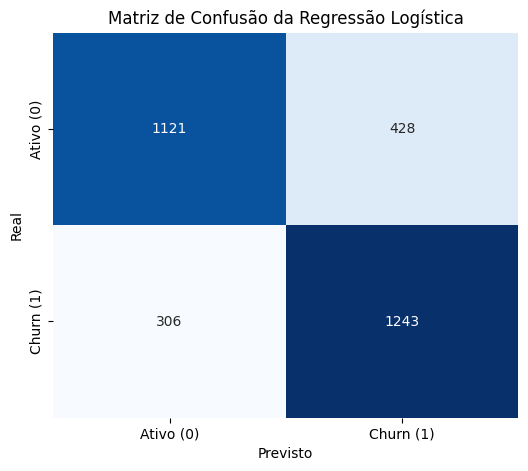

In [31]:
# Visualizando a Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ativo (0)', 'Churn (1)'], yticklabels=['Ativo (0)', 'Churn (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão da Regressão Logística')
plt.show()

In [32]:
# Inicializando o StandardScaler para os dados do RandomUnderSampler
r_scaler = StandardScaler()

# Aplicando a padronização aos dados X_rus
X_rus_scaled = r_scaler.fit_transform(X_rus)

# Convertendo o array padronizado de volta para um DataFrame
X_rus_scaled_df = pd.DataFrame(X_rus_scaled, columns=X_rus.columns)

print("Primeiras 5 linhas de X_rus após a padronização:")
display(X_rus_scaled_df.head())

Primeiras 5 linhas de X_rus após a padronização:


,idoso,tempo_contrato,cobrança_mensal,onehotencoder__genero_masculino,onehotencoder__parceiro_sim,onehotencoder__dependentes_sim,onehotencoder__servico_telefonico_sim,onehotencoder__multiplas_linhas_não,onehotencoder__multiplas_linhas_sim,onehotencoder__servico_internet_dsl,...,onehotencoder__streaming_filmes_não,onehotencoder__streaming_filmes_sim,onehotencoder__contrato_dois anos,onehotencoder__contrato_mensal,onehotencoder__contrato_um ano,onehotencoder__fatura_online_sim,onehotencoder__metodo_pagamento_cartão de crédito (automático),onehotencoder__metodo_pagamento_cheque eletrônico,onehotencoder__metodo_pagamento_cheque postal,onehotencoder__metodo_pagamento_transferência bancária (automática)
0,-0.482966,0.973179,-0.269164,0.992537,-0.887985,-0.590738,0.317343,-0.941262,1.131047,1.503922,...,1.163574,-0.822334,-0.459221,-1.388227,2.229629,-1.367833,2.092467,-0.837503,-0.517251,-0.485492
1,-0.482966,0.013275,-0.265716,0.992537,1.126146,1.692798,-3.151162,-0.941262,-0.884136,1.503922,...,-0.859421,1.216051,-0.459221,-1.388227,2.229629,0.731083,2.092467,-0.837503,-0.517251,-0.485492
2,2.070538,0.221950,0.891023,0.992537,1.126146,-0.590738,0.317343,1.062404,-0.884136,-0.664928,...,-0.859421,1.216051,-0.459221,-1.388227,2.229629,0.731083,-0.477905,1.194026,-0.517251,-0.485492
3,-0.482966,-1.071833,-1.634494,-1.007519,-0.887985,-0.590738,0.317343,1.062404,-0.884136,-0.664928,...,-0.859421,-0.822334,-0.459221,0.720344,-0.448505,-1.367833,-0.477905,-0.837503,1.933298,-0.485492
4,-0.482966,-0.195399,-1.656905,0.992537,1.126146,1.692798,0.317343,1.062404,-0.884136,-0.664928,...,-0.859421,-0.822334,-0.459221,-1.388227,2.229629,-1.367833,-0.477905,-0.837503,1.933298,-0.485492


In [33]:
# Dividindo os dados em conjuntos de treinamento e teste para os dados com RandomUnderSampler
X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(
    X_rus_scaled_df, y_rus, test_size=0.3, random_state=42, stratify=y_rus
)

print(f"Formato de X_train_rus: {X_train_rus.shape}")
print(f"Formato de X_test_rus: {X_test_rus.shape}")
print(f"Formato de y_train_rus: {y_train_rus.shape}")
print(f"Formato de y_test_rus: {y_test_rus.shape}")

Formato de X_train_rus: (2616, 32)
Formato de X_test_rus: (1122, 32)
Formato de y_train_rus: (2616,)
Formato de y_test_rus: (1122,)


In [35]:
# Inicializando e treinando o modelo de Regressão Logística nos dados com undersampling
log_reg_model_rus = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model_rus.fit(X_train_rus, y_train_rus)

# Fazendo previsões no conjunto de teste
y_pred_rus = log_reg_model_rus.predict(X_test_rus)

# Avaliando o modelo
accuracy_rus = accuracy_score(y_test_rus, y_pred_rus)
precision_rus = precision_score(y_test_rus, y_pred_rus)
recall_rus = recall_score(y_test_rus, y_pred_rus)
f1_rus = f1_score(y_test_rus, y_pred_rus)
conf_matrix_rus = confusion_matrix(y_test_rus, y_pred_rus)

print(f"--- Desempenho da Regressão Logística com RandomUnderSampler ---")
print(f"Acurácia: {accuracy_rus:.4f}")
print(f"Precisão: {precision_rus:.4f}")
print(f"Recall: {recall_rus:.4f}")
print(f"F1-Score: {f1_rus:.4f}")

--- Desempenho da Regressão Logística com RandomUnderSampler ---
Acurácia: 0.7594
Precisão: 0.7358
Recall: 0.8093
F1-Score: 0.7708


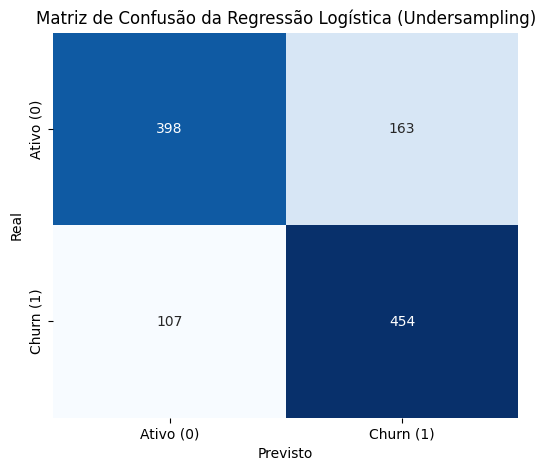

In [36]:
# Visualizando a Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rus, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ativo (0)', 'Churn (1)'], yticklabels=['Ativo (0)', 'Churn (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão da Regressão Logística (Undersampling)')
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Inicializando e treinando o modelo Random Forest
# Usaremos os dados balanceados por SMOTE (X_train, y_train)
random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100) # n_estimators é o número de árvores na floresta
random_forest_model.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred_rf = random_forest_model.predict(X_test)

# Avaliando o modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"--- Desempenho do Random Forest com SMOTE ---")
print(f"Acurácia: {accuracy_rf:.4f}")
print(f"Precisão: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

--- Desempenho do Random Forest com SMOTE ---
Acurácia: 0.8525
Precisão: 0.8645
Recall: 0.8360
F1-Score: 0.8500


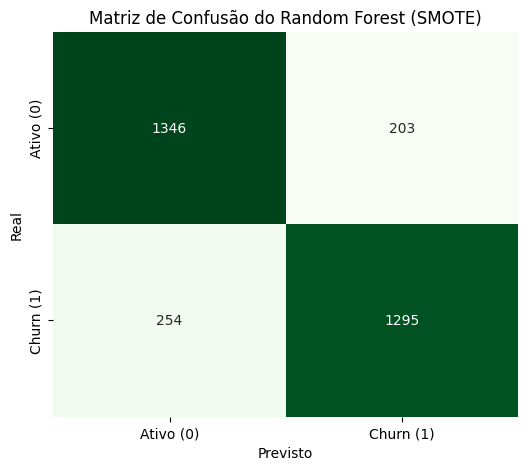

In [38]:
# Visualizando a Matriz de Confusão para Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Ativo (0)', 'Churn (1)'], yticklabels=['Ativo (0)', 'Churn (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Random Forest (SMOTE)')
plt.show()

--- Verificando Colunas com Alta Correlação (limite: |0.9|) ---
Nenhuma coluna com alta correlação (>0.90) encontrada.


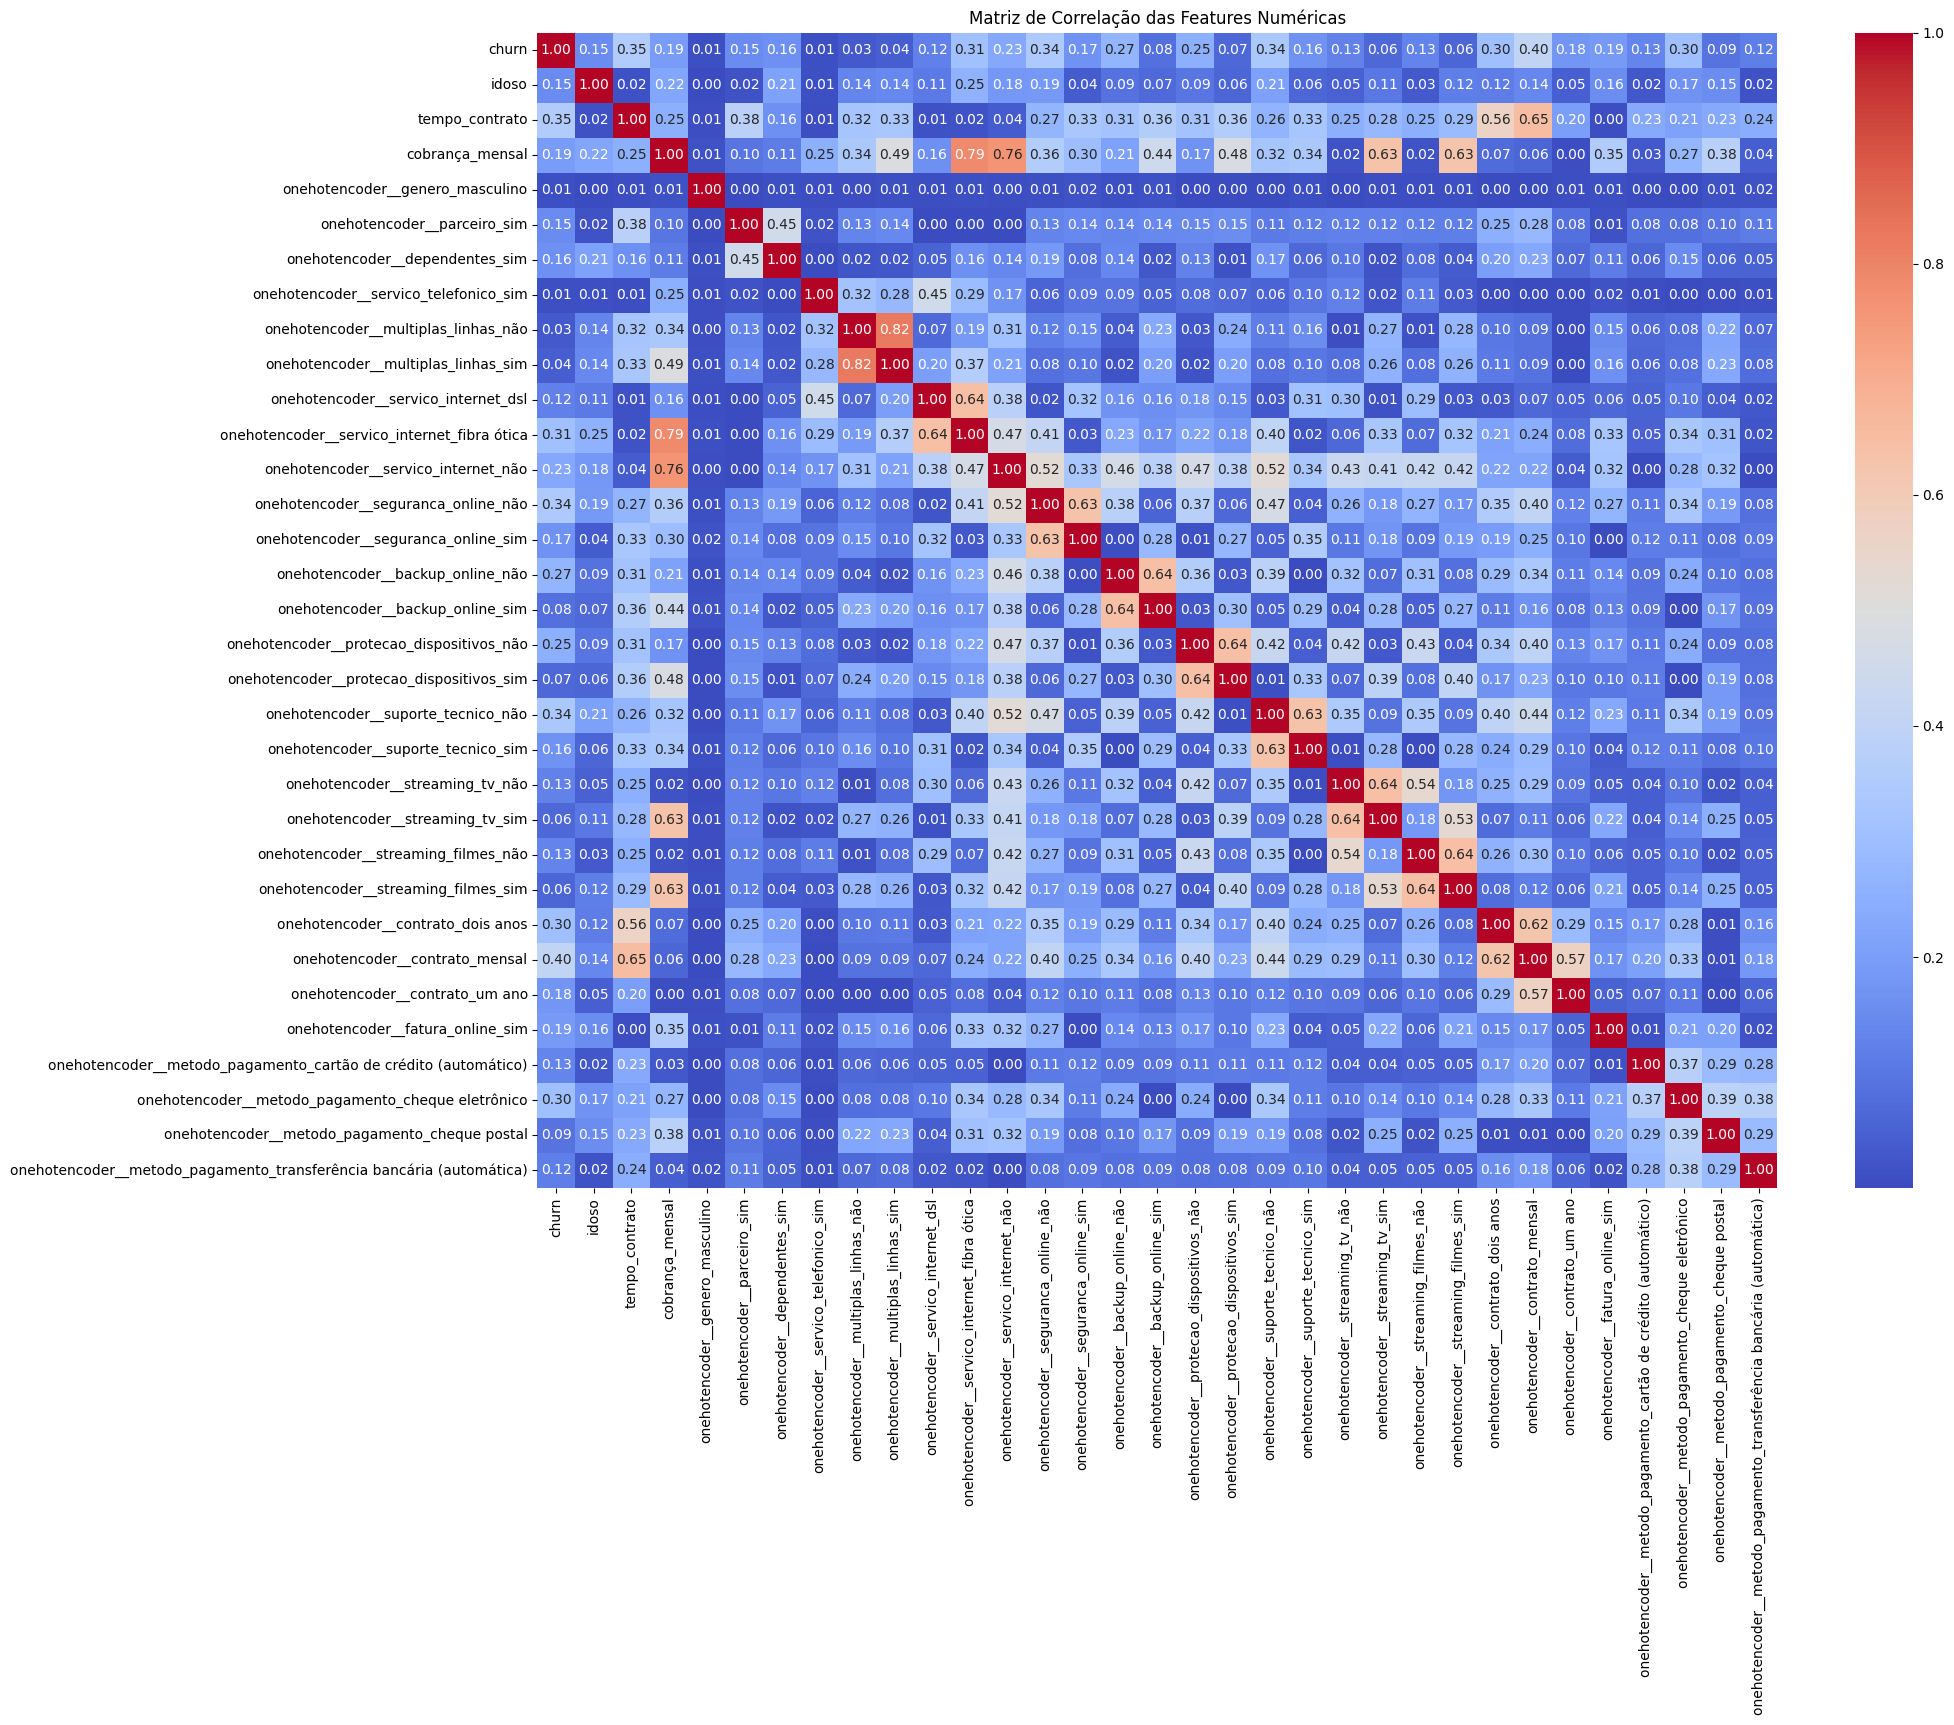

In [40]:
# Realizando uma nova análise de Correlação para colunas numéricas
print('--- Verificando Colunas com Alta Correlação (limite: |0.9|) ---')
correlation_matrix = df_encoding.corr(numeric_only=True).abs()

upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

to_drop_high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

if to_drop_high_corr:
    print(f'Colunas com alta correlação (para remover uma): {to_drop_high_corr}')
else:
    print('Nenhuma coluna com alta correlação (>0.90) encontrada.')

# Exibindo a matriz de correlação para uma inspeção visual
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Features Numéricas')
plt.show()

## Analisando o tempo de contrato e a cobrança mensal vs churn

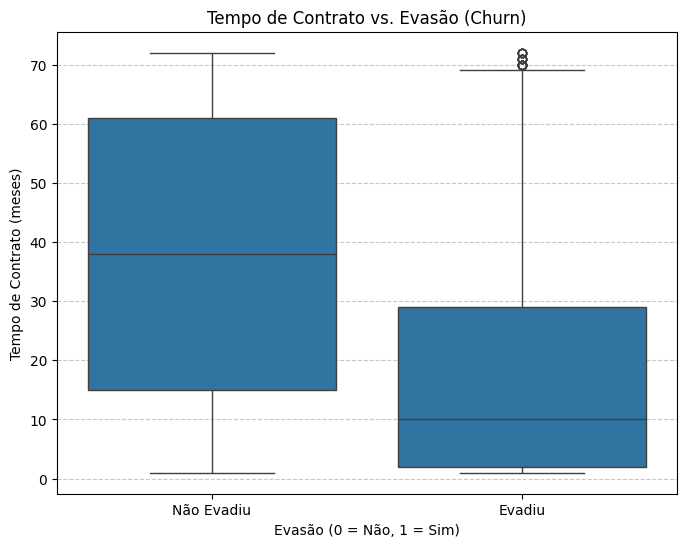

In [41]:
# Boxplot para Tempo de Contrato vs. Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='tempo_contrato', data=df_encoding)
plt.title('Tempo de Contrato vs. Evasão (Churn)')
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Tempo de Contrato (meses)')
plt.xticks([0, 1], ['Não Evadiu', 'Evadiu'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

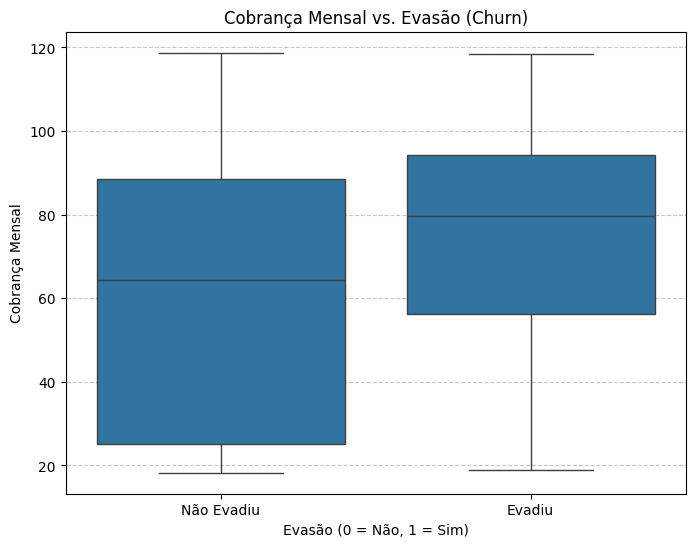

In [42]:
# Boxplot para Cobrança Mensal vs. Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='cobrança_mensal', data=df_encoding)
plt.title('Cobrança Mensal vs. Evasão (Churn)')
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Cobrança Mensal')
plt.xticks([0, 1], ['Não Evadiu', 'Evadiu'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Otimizando os hiperparâmetros com GridSearchCV

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definindo a grade de hiperparâmetros para otimização
param_grid = {
    'n_estimators': [100, 200, 300],  # Número de árvores na floresta
    'max_depth': [10, 20, 30, None],  # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10], # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4],   # Número mínimo de amostras em um nó folha
    'criterion': ['gini', 'entropy']  # Função para medir a qualidade de uma divisão
}

# Inicializando o modelo Random Forest
rf_model_grid = RandomForestClassifier(random_state=42)

# Inicializando GridSearchCV
# cv=5 significa 5-fold cross-validation
# scoring='f1' porque é uma métrica balanceada para classes desbalanceadas
grid_search = GridSearchCV(estimator=rf_model_grid, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1')

# Executando a busca em grade nos dados de treinamento (SMOTE-balanced)
grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)
print("Melhor F1-Score médio de validação cruzada:", grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Melhores hiperparâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Melhor F1-Score médio de validação cruzada: 0.8535619598754417


In [49]:
# Obtendo o melhor modelo a partir da busca em grade (para garantir que esteja definido)
best_rf_model = grid_search.best_estimator_

# Treinando o melhor modelo Random Forest nos dados com undersampling
best_rf_model.fit(X_train_rus, y_train_rus)

# Fazendo previsões no conjunto de teste com undersampling
y_pred_rf_rus = best_rf_model.predict(X_test_rus)

# Avaliando o melhor modelo Random Forest com undersampling
accuracy_rf_rus = accuracy_score(y_test_rus, y_pred_rf_rus)
precision_rf_rus = precision_score(y_test_rus, y_pred_rf_rus)
recall_rf_rus = recall_score(y_test_rus, y_pred_rf_rus)
f1_rf_rus = f1_score(y_test_rus, y_pred_rf_rus)
conf_matrix_rf_rus = confusion_matrix(y_test_rus, y_pred_rf_rus)

print(f"--- Desempenho do Melhor Random Forest (RandomUnderSampler) ---")
print(f"Acurácia: {accuracy_rf_rus:.4f}")
print(f"Precisão: {precision_rf_rus:.4f}")
print(f"Recall: {recall_rf_rus:.4f}")
print(f"F1-Score: {f1_rf_rus:.4f}")

--- Desempenho do Melhor Random Forest (RandomUnderSampler) ---
Acurácia: 0.7656
Precisão: 0.7388
Recall: 0.8217
F1-Score: 0.7781


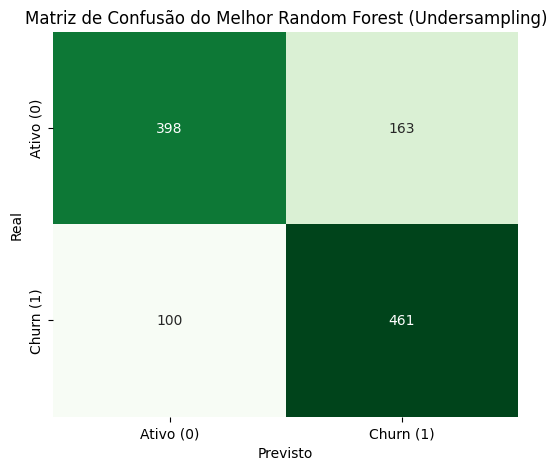

In [50]:
# Visualizando a Matriz de Confusão para o Melhor Random Forest (Undersampling)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf_rus, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Ativo (0)', 'Churn (1)'], yticklabels=['Ativo (0)', 'Churn (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Melhor Random Forest (Undersampling)')
plt.show()

In [52]:
# Obtendo o melhor modelo a partir da busca em grade
best_rf_model = grid_search.best_estimator_

# Fazendo previsões no conjunto de teste com o melhor modelo
y_pred_best_rf = best_rf_model.predict(X_test)

# Avaliando o melhor modelo Random Forest
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)
conf_matrix_best_rf = confusion_matrix(y_test, y_pred_best_rf)

print(f"--- Desempenho do Melhor Random Forest (SMOTE) ---")
print(f"Acurácia: {accuracy_best_rf:.4f}")
print(f"Precisão: {precision_best_rf:.4f}")
print(f"Recall: {recall_best_rf:.4f}")
print(f"F1-Score: {f1_best_rf:.4f}")

--- Desempenho do Melhor Random Forest (SMOTE) ---
Acurácia: 0.8128
Precisão: 0.7612
Recall: 0.9116
F1-Score: 0.8296


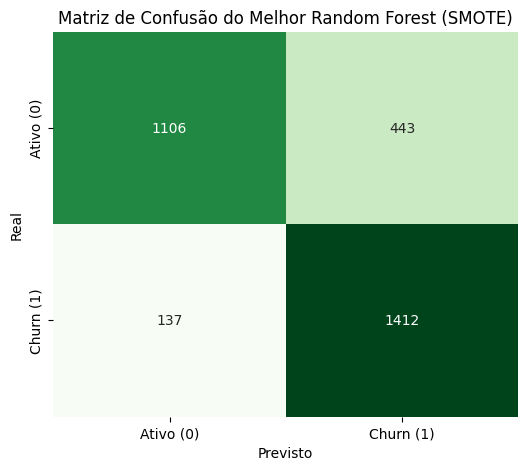

In [53]:
# Visualizando a Matriz de Confusão para o Melhor Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_best_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Ativo (0)', 'Churn (1)'], yticklabels=['Ativo (0)', 'Churn (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Melhor Random Forest (SMOTE)')
plt.show()

## Salvando o Modelo Random Forest com SMOTE

In [60]:
import pickle

try:
  with open('model_previsao_churn.pkl', 'wb') as file:
      pickle.dump(random_forest_model, file)
  print("Modelo salvo com sucesso!!!")
except Exception as e:
  print(f'Erro ao salvar o modelo: {e}')

Modelo salvo com sucesso!!!
